In [3]:
!pip install --upgrade protobuf==3.20.3 tensorflow keras opencv-python pandas numpy scikit-learn matplotlib

import os, glob, math, random, cv2, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, TimeDistributed, GlobalAveragePooling2D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence, to_categorical

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 944.9 kB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 10.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 82.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 106.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Unins

In [7]:
BASE_PATH = "/kaggle/input/datasets/bubblu123/intruder-class3/Intruder_classification/intruder_project"   
ANOMALY_DIR = os.path.join(BASE_PATH, "anomaly")
NORMAL_DIR = os.path.join(BASE_PATH, "normal")
OUT_MODEL = "/kaggle/working/lrcn_3cls_mobilenetv2.keras"

# Parameters
IMG_SIZE = (224, 224)
FRAMES_PER_CLIP = 40
BATCH_SIZE = 4           
EPOCHS = 15

In [8]:
CLASSES = ["RoadAccidents", "Robbery", "normal"]

rows = []
# Collect Anomaly clips (RoadAccidents and Robbery only)
for cls in ["RoadAccidents", "Robbery"]:
    folder = os.path.join(ANOMALY_DIR, cls)
    if os.path.isdir(folder):
        for p in glob.glob(os.path.join(folder, "*")):
            if p.lower().endswith((".mp4", ".avi", ".mkv", ".mov")):
                rows.append({"path": p, "label": cls})

# Collect Normal clips
for p in glob.glob(os.path.join(NORMAL_DIR, "*")):
    if p.lower().endswith((".mp4", ".avi", ".mkv", ".mov")):
        rows.append({"path": p, "label": "normal"})

df = pd.DataFrame(rows)
print("Total videos:", len(df))
df.sample(5)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.to_csv("/kaggle/working/labels.csv", index=False)
df.head()

# Stratified Split to maintain class balance
train_df, val_df = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=42)

# ==========================================
# STEP 3: PREPROCESSING & DATA GENERATOR
# ==========================================
def load_clip_as_array(path, frames=FRAMES_PER_CLIP, size=IMG_SIZE):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Uniform sampling logic
    if total <= 0:
        return np.zeros((frames, size[0], size[1], 3), dtype="float32")
    
    idxs = np.linspace(0, total - 1, frames).astype(int).tolist()
    frames_out = []
    
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            # Fallback for corrupt frames
            frame = np.zeros((size[0], size[1], 3), dtype="uint8")
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
        
        frames_out.append(frame.astype("float32") / 255.0)
        
    cap.release()
    return np.stack(frames_out, axis=0)

class VideoSequence(Sequence):
    def __init__(self, df, batch_size=BATCH_SIZE, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1.0).reset_index(drop=True)

    def __getitem__(self, idx):
        batch = self.df.iloc[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_batch, y_batch = [], []
        for _, row in batch.iterrows():
            X_batch.append(load_clip_as_array(row["path"]))
            y_batch.append(CLASSES.index(row["label"]))
        return np.array(X_batch), to_categorical(np.array(y_batch), num_classes=len(CLASSES))

train_gen = VideoSequence(train_df, batch_size=BATCH_SIZE, shuffle=True)
val_gen = VideoSequence(val_df, batch_size=BATCH_SIZE, shuffle=False)



Total videos: 450


In [10]:
# ==========================================
# STEP 4: MODEL ARCHITECTURE (PHASE 1)
# ==========================================
def build_phase1_lrcn(frames=FRAMES_PER_CLIP, size=IMG_SIZE, num_classes=len(CLASSES)):
    # Load MobileNetV2 with ImageNet weights
    base_cnn = MobileNetV2(include_top=False, weights="imagenet", input_shape=(size[0], size[1], 3))
    
    # PHASE 1: Entire backbone is frozen
    base_cnn.trainable = False 

    inp = Input(shape=(frames, size[0], size[1], 3))
    
    # TimeDistributed applies the CNN to each frame
    x = TimeDistributed(base_cnn)(inp)
    x = TimeDistributed(GlobalAveragePooling2D())(x) 
    
    # Temporal Learning
    x = LSTM(256, return_sequences=False)(x)
    
    # Classification Head
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.7)(x)
    x = BatchNormalization()(x)
    out = Dense(num_classes, activation="softmax")(x)
    
    return Model(inp, out)

model = build_phase1_lrcn()
model.compile(optimizer=Adam(learning_rate=1e-3), 
              loss="categorical_crossentropy", 
              metrics=["accuracy"])



In [11]:
# ==========================================
# STEP 5: TRAINING CALLBACKS & EXECUTION
# ==========================================
ckpt = ModelCheckpoint("lrcn_3class_phase1.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
es = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)

print("\nStarting Phase 1 Training (Frozen Backbone)...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[ckpt, es, rlr]
)


Starting Phase 1 Training (Frozen Backbone)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1774603180.409009     173 cuda_dnn.cc:529] Loaded cuDNN version 91002


90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3620 - loss: 1.2889
Epoch 1: val_accuracy improved from -inf to 0.37778, saving model to lrcn_3class_phase1.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 823s 7s/step - accuracy: 0.3622 - loss: 1.2883 - val_accuracy: 0.3778 - val_loss: 1.0798 - learning_rate: 0.0010
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3222 - loss: 1.2183
Epoch 2: val_accuracy improved from 0.37778 to 0.52222, saving model to lrcn_3class_phase1.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 538s 6s/step - accuracy: 0.3224 - loss: 1.2178 - val_accuracy: 0.5222 - val_loss: 1.0103 - learning_rate: 0.0010
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3667 - loss: 1.1724
Epoch 3: val_accuracy improved from 0.52222 to 0.54444, saving model to lrcn_3class_phase1.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 539s 6s/step - accuracy: 0.3669 - loss: 1.1718 - val_accuracy: 0.5444 - val_loss: 1.0213 - learning_rate: 0.0010
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - acc

In [12]:
# Load and check the output shape
temp_model = tf.keras.models.load_model("lrcn_3class_phase1.keras")
print(f"Verified Output Classes: {temp_model.output_shape[-1]}") 
# This should print '3'

Verified Output Classes: 3


In [13]:
from IPython.display import FileLink

# This creates a blue clickable link in your notebook output
FileLink(r'lrcn_3class_phase1.keras')

/kaggle/working/lrcn_3class_phase1.keras

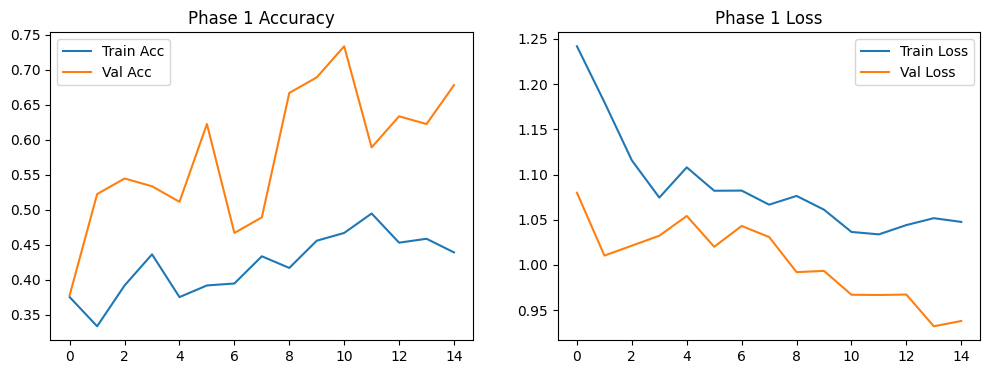

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Phase 1 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Phase 1 Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step

--- Inference Result ---
Video: normal_test.mp4
Prediction: normal (38.64%)


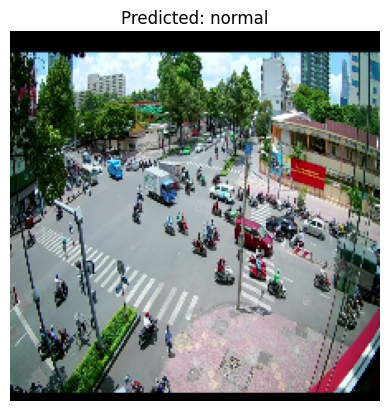

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_video(video_path, model, frames_per_clip=40, img_size=(224, 224)):
    # 1. Load and Preprocess Video
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames <= 0:
        print("Error: Could not read video.")
        return

    # Uniformly sample frames to match model input
    idxs = np.linspace(0, total_frames - 1, frames_per_clip).astype(int)
    video_frames = []
    
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret: break
        
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, img_size)
        video_frames.append(frame.astype("float32") / 255.0)
    
    cap.release()
    
    # 2. Prepare for Model (Add Batch Dimension)
    # Shape: (1, 40, 224, 224, 3)
    input_data = np.expand_dims(np.array(video_frames), axis=0)
    
    # 3. Perform Inference
    predictions = model.predict(input_data)
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx] * 100
    
    # 4. Display Result
    # Map back to our 3-class list: ["RoadAccidents", "Robbery", "normal"]
    result_label = CLASSES[predicted_idx]
    
    print(f"\n--- Inference Result ---")
    print(f"Video: {os.path.basename(video_path)}")
    print(f"Prediction: {result_label} ({confidence:.2f}%)")
    
    # Show a sample frame from the clip
    plt.imshow(video_frames[len(video_frames)//2])
    plt.title(f"Predicted: {result_label}")
    plt.axis('off')
    plt.show()

# --- RUN THE TEST ---
# Provide a path to a video in your dataset or a new one
test_video_path = "/kaggle/input/datasets/bubblu123/testing/normal_test.mp4" 
predict_video(test_video_path, model)